# Second-Order Interactions

The other notebooks only look at first-order Shapley values - one number per superpixel. Here we ask Shapiq Vision for **second-order interactions**
too: how much a *pair* of superpixels contributes jointly, beyond what their individual values would predict. Same model, image, and superpixel
setup, just with `max_order=2` instead of `1`.

The result is visualized with the **upset plot**: the top bars show the strongest individual interactions (both single superpixels and pairs), and the matrix underneath shows which superpixels each bar corresponds to.

In [1]:
!pip install "git+https://github.com/S2k-1/shapiq.git@feature/pr_final" captum scikit-image --quiet

## 1 · Setup

In [2]:
import numpy as np
import torch
from PIL import Image
from torchvision import models, transforms
from skimage.segmentation import slic, mark_boundaries
import matplotlib.pyplot as plt

from shapiq.vision import ClassificationArchitecture, ImageExplainer, MeanColorMasking
from shapiq.vision.players import CustomPlayerStrategy
from shapiq.plot import upset_plot

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

/home/barbara/XAI-Praktikum/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


## 2 · Config

- `N_SEGMENTS` - kept small on purpose: second-order interactions live on a *pairs* of players, so the number of possible pairs grows quadratically with the number of superpixels. Fewer, larger superpixels keep the interaction space (and the plot) legible.
- `MAX_ORDER = 2` - the key change from the other notebooks; this is what asks Shapiq Vision for pairwise interactions in addition to individual values.
- `INDEX = "k-SII"` - the k-Shapley Interaction Index, the standard choice for higher-order Shapley interactions (order-1 reduces to the usual Shapley value, order-2 adds pairwise interaction terms).

In [13]:
IMAGE_PATH = "data/guitardog.png"
N_SEGMENTS = 40
BUDGET = 2048

MAX_ORDER = 2
INDEX = "k-SII"
N_INTERACTIONS = 12

## 3 · Load the image and the model

Same ResNet-18 (ImageNet) setup as the comparison notebook.

In [9]:
pil_image = Image.open(IMAGE_PATH).convert("RGB")

resize_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])
resized_image = resize_crop(pil_image)
image_np = np.array(resized_image)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval().to(device)
categories = weights.meta["categories"]

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()
tensor_image = normalize(to_tensor(resized_image)).unsqueeze(0).to(device)

with torch.no_grad():
    probs = torch.softmax(model(tensor_image), dim=1)[0]
target_class = int(torch.argmax(probs).item())

print(f"Explaining class: '{categories[target_class]}' ({probs[target_class].item() * 100:.1f}%)")

Explaining class: 'acoustic guitar' (40.2%)


## 4 · Define the players: superpixel regions

Requested 40 superpixels, got 24 players


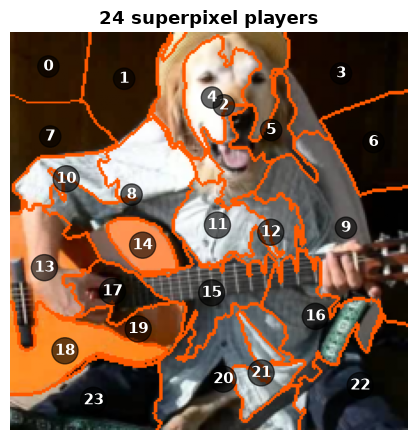

In [10]:
segments = slic(image_np, n_segments=N_SEGMENTS, compactness=12, sigma=1, start_label=0)
n_players = int(segments.max()) + 1
print(f"Requested {N_SEGMENTS} superpixels, got {n_players} players")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(mark_boundaries(image_np, segments, color=(1, 0.35, 0)))
for i in range(n_players):
    ys, xs = np.where(segments == i)
    ax.text(xs.mean(), ys.mean(), str(i), color="white", fontsize=11, fontweight="bold",
            ha="center", va="center", bbox=dict(boxstyle="circle", facecolor="black", alpha=0.6, pad=0.2))
ax.set_title(f"{n_players} superpixel players", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5 · Run Shapiq Vision at `max_order=2`

In [11]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

class CountedModel(torch.nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model
        self.n_calls = 0

    def forward(self, x):
        self.n_calls += x.shape[0]
        return self.model(normalize(x))


counted_model = CountedModel(model).eval().to(device)

architecture = ClassificationArchitecture(
    model=counted_model,
    masking_strategy=MeanColorMasking(),
    player_strategy=CustomPlayerStrategy(segments),
)
explainer = ImageExplainer(
    model=architecture,
    data=image_np,
    class_index=target_class,
    index=INDEX,
    max_order=MAX_ORDER,
    random_state=SEED,
)
iv = explainer.explain(budget=BUDGET)
print(f"done - {counted_model.n_calls} model calls")
print(iv)

done - 2049 model calls
InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=2048,
    n_players=24, baseline_value=0.5382564067840576,
    Top 10 interactions:
        (15,): 3.7173697162518273
        (19,): 2.0000656426502914
        (2, 11): 1.6883634350959493
        (14,): 1.5656435727197215
        (15, 17): 1.4910489674834515
        (16,): 1.4736863615901745
        (13,): 1.3495115913354248
        (2,): -1.3081273069908423
        (14, 17): -1.337290720427352
        (11,): -1.6034158400382528
)


## 6 · Upset plot

Bars are the top individual interactions (both single superpixels and pairs), sorted by absolute value. The matrix underneath marks which
superpixel(s) each bar involves - a bar with two dots connected by a line is a pairwise interaction; a bar with one dot is an ordinary first-order value.

`N_INTERACTIONS` (set in Section 2) controls how many bars are shown, sorted by absolute interaction strength - lower it for a cleaner plot, raise it (or set it to `0`) to see every interaction Shapiq Vision computed.

showing top 12 of 301 computed interactions


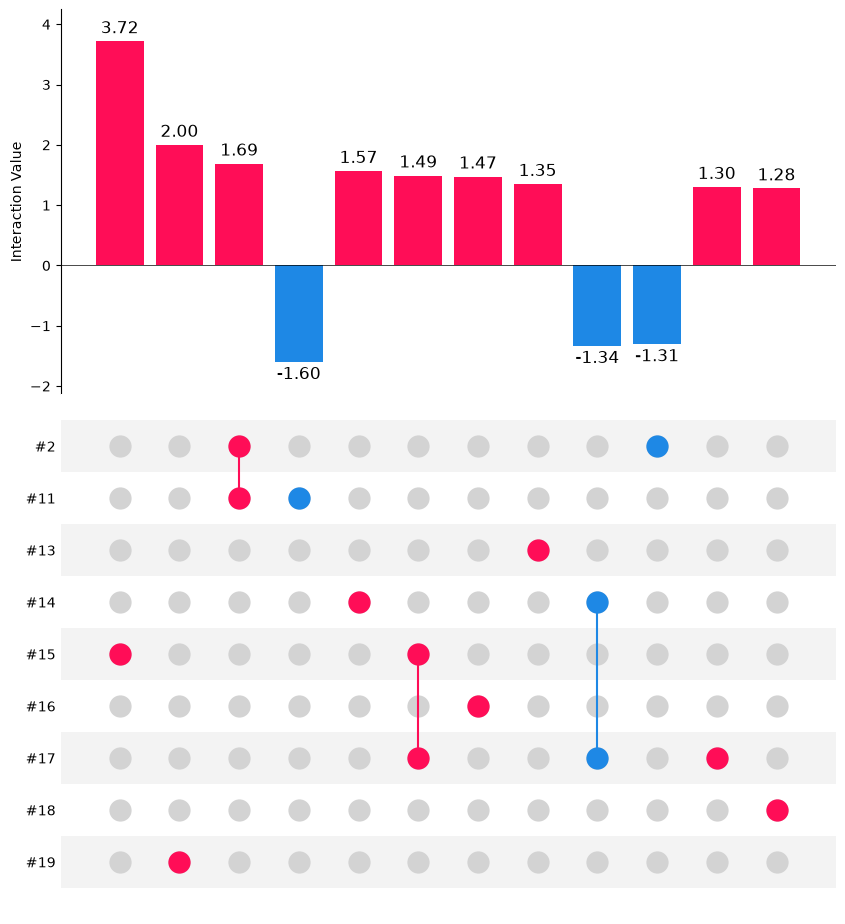

In [14]:
feature_names = [f"#{i}" for i in range(n_players)]
n_total = len(iv.interaction_lookup)
print(f"showing top {min(N_INTERACTIONS, n_total)} of {n_total} computed interactions")

upset_plot(
    iv,
    n_interactions=N_INTERACTIONS,
    feature_names=feature_names,
    color_matrix=True,
    all_features=False,
    show=True,
)